# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


# **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.3 huggingface_hub==0.30.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.2/481.2 kB 21.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.3 which is incompatible.
google-adk 1.28.0 requires requests<3.0.0,>=2.32.4, but you have requests 2.32.3 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.30.1 which is incompatible.
gradio 5.50.0 requires huggingface-hub<2.0,>=0.33.5, but you have huggingface-hub 0.30.1 which is incompatible.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggin

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [2]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn import metrics
from sklearn.pipeline import Pipeline # Import Pipeline
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)


# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

# **Loading the dataset**

In [3]:
super_kart = pd.read_csv('SuperKart.csv')

In [4]:
# copying data to another varaible to avoid any changes to original data
data = super_kart.copy()

# **Data Overview**

### Displaying the first and last 5 rows of the dataset

In [5]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [6]:
data.tail()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


In [7]:
data.sample(10)

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8648,FD4276,15.70,Low Sugar,0.015,Snack Foods,163.16,OUT003,1999,Medium,Tier 1,Departmental Store,4471.91
6850,DR4602,13.93,Low Sugar,0.037,Hard Drinks,164.37,OUT001,1987,High,Tier 2,Supermarket Type1,4097.06
2489,NC7139,12.75,No Sugar,0.042,Household,135.09,OUT004,2009,Medium,Tier 2,Supermarket Type2,3231.95
607,FD1123,12.92,Regular,0.028,Fruits and Vegetables,165.72,OUT004,2009,Medium,Tier 2,Supermarket Type2,3897.10
2023,FD6695,11.04,Low Sugar,0.019,Canned,99.51,OUT002,1998,Small,Tier 3,Food Mart,2116.79
8687,FD4359,12.22,Low Sugar,0.032,Canned,137.13,OUT004,2009,Medium,Tier 2,Supermarket Type2,3153.74
7101,NC273,14.34,No Sugar,0.031,Health and Hygiene,121.28,OUT004,2009,Medium,Tier 2,Supermarket Type2,5130.16
1009,FD2245,12.49,Low Sugar,0.171,Snack Foods,142.49,OUT004,2009,Medium,Tier 2,Supermarket Type2,3323.57
6406,FD7663,11.14,Low Sugar,0.015,Dairy,201.78,OUT003,1999,Medium,Tier 1,Departmental Store,4231.98
6383,FD30,15.47,Regular,0.070,Dairy,196.00,OUT001,1987,High,Tier 2,Supermarket Type1,2379.21


### Understand the shape of the dataset.

In [8]:
data.shape

(8763, 12)

* There are 25480 observations and 12 columns in the dataset

In [9]:
# fixing column names
data.columns = [c.replace(" ", "_") for c in data.columns]

### Check the data types of the columns for the dataset.

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


**Data Overview:**
* The dataset contains 8763 entries and 12 columns. All columns have no missing values.

* **Product_Id** is a unique identifier and is not used for analysis. we can drop it.



In [11]:
# When we check the data and see that there is no pattern in the id column. so we can drop it.
data.drop("Product_Id", axis=1, inplace=True)

In [12]:
# Check the info of data set after dropping the columns
# We see the column is now dropped from data set.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Weight             8763 non-null   float64
 1   Product_Sugar_Content      8763 non-null   object 
 2   Product_Allocated_Area     8763 non-null   float64
 3   Product_Type               8763 non-null   object 
 4   Product_MRP                8763 non-null   float64
 5   Store_Id                   8763 non-null   object 
 6   Store_Establishment_Year   8763 non-null   int64  
 7   Store_Size                 8763 non-null   object 
 8   Store_Location_City_Type   8763 non-null   object 
 9   Store_Type                 8763 non-null   object 
 10  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(6)
memory usage: 753.2+ KB


### Checking for duplicate values

In [13]:
# let's check for duplicate observations
data.duplicated().sum()

np.int64(0)

* There are no duplicates in the data set.

### Checking Statistical Summary of the dataset

In [14]:
#Descriptive Statistics for Numerical Columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


### Observations from Statistical Summary for Numerical Features

*   **Product_Weight**:
    *   Ranges from 4.00 to 22.00, with a mean of 12.65 and a standard deviation of 2.22. The distribution appears relatively balanced around the mean, with the median (12.66) close to the mean.

*   **Product_Allocated_Area**:
    *   The values range from 0.004 to 0.298. The mean is 0.069, and the median is 0.056. The mean being higher than the median, along with the relatively large standard deviation (0.048) compared to the mean, suggests a right-skewed distribution, indicating a few products might have a much larger allocated area.

*   **Product_MRP**:
    *   Maximum Retail Price ranges from 31.00 to 266.00, with an average of 147.03. The mean and median (146.74) are very close, suggesting a fairly symmetrical distribution for MRP.

*   **Store_Establishment_Year**:
    *   Stores were established between 1987 and 2009. The mean establishment year is 2002.03, and the median is 2009.00. The 75th percentile also being 2009 indicates a significant number of stores were established in the later years of this range.

*   **Product_Store_Sales_Total**:
    *   Sales figures range widely from 33.00 to 8000.00, with a mean of 3464.00. The median (3452.34) is very close to the mean, suggesting a relatively symmetrical distribution for sales, though the large range indicates high variability.



### Descriptive Statistics for Categorical Columns

In [15]:
#Descriptive Statistics for Categorical Columns
data.describe(include='object').T

,count,unique,top,freq
Product_Sugar_Content,8763,4,Low Sugar,4885
Product_Type,8763,16,Fruits and Vegetables,1249
Store_Id,8763,4,OUT004,4676
Store_Size,8763,3,Medium,6025
Store_Location_City_Type,8763,3,Tier 2,6262
Store_Type,8763,4,Supermarket Type2,4676


### Observations on Descriptive Statistics for Categorical Columns:

*   **Product_Sugar_Content**:
    *   There are 4 unique categories. 'Low Sugar' is the most frequent, accounting for 4885 entries, indicating a preference or abundance of low sugar products.

*   **Product_Type**:
    *   There are 16 unique product types. 'Fruits and Vegetables' is the most common category, with 1249 entries, suggesting it's a significant portion of the inventory.

*   **Store_Id**:
    *   There are 4 unique store identifiers. 'OUT004' is the most frequent, appearing 4676 times. This might indicate that OUT004 is either a larger store or has a higher number of products listed.

*   **Store_Size**:
    *   There are 3 unique store sizes. 'Medium' is the most prevalent size, with 6025 entries, suggesting that most stores in the dataset are of medium size.

*   **Store_Location_City_Type**:
    *   There are 3 unique city types. 'Tier 2' is the most frequent location, with 6262 entries, indicating a majority of stores are located in Tier 2 cities.

*   **Store_Type**:
    *   There are 4 unique store types. 'Supermarket Type2' is the most frequent, with 4676 entries, mirroring the frequency of 'OUT004' (as OUT004 is likely a Supermarket Type2 store).


### Check all unique values in each categorical column

In [16]:
# list of all categorical variables
cat_col = data.select_dtypes(include='object').columns.tolist()

# printing the number of occurrences of each unique value in each categorical column
for column in cat_col:
    print(data[column].value_counts(normalize=True))
    print("-" * 50)

Product_Sugar_Content
Low Sugar    0.557457
Regular      0.256875
No Sugar     0.173342
reg          0.012325
Name: proportion, dtype: float64
--------------------------------------------------
Product_Type
Fruits and Vegetables    0.142531
Snack Foods              0.131119
Frozen Foods             0.092548
Dairy                    0.090836
Household                0.084446
Baking Goods             0.081707
Canned                   0.077257
Health and Hygiene       0.071665
Meat                     0.070524
Soft Drinks              0.059226
Breads                   0.022823
Hard Drinks              0.021226
Others                   0.017232
Starchy Foods            0.016090
Breakfast                0.012096
Seafood                  0.008673
Name: proportion, dtype: float64
--------------------------------------------------
Store_Id
OUT004    0.533607
OUT001    0.180988
OUT003    0.153943
OUT002    0.131462
Name: proportion, dtype: float64
-----------------------------------------------

In [17]:
# In the data set, Lets segregate the list of features based on type of column for making more impactful visualizations.

# Selecting numerical columns and categorical columns dynamically
all_features = data.columns.tolist()

# Identify categorical columns (object dtype) excluding 'case_id'
Cat_features = data.select_dtypes(include='object').columns.tolist()

# Identify numerical columns (int64 or float64 dtypes)
num_features = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('All Features: ' + str(all_features))
print('Numerical Features: ' + str(num_features))
print('Categorical Features: ' + str(Cat_features))

All Features: ['Product_Weight', 'Product_Sugar_Content', 'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id', 'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type', 'Store_Type', 'Product_Store_Sales_Total']
Numerical Features: ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total']
Categorical Features: ['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']


# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

We will plot Histograms, boxplots for Numeric Variabels to understand the data better.

Bar plots for visualising the categorical variables.

### Historgram plots

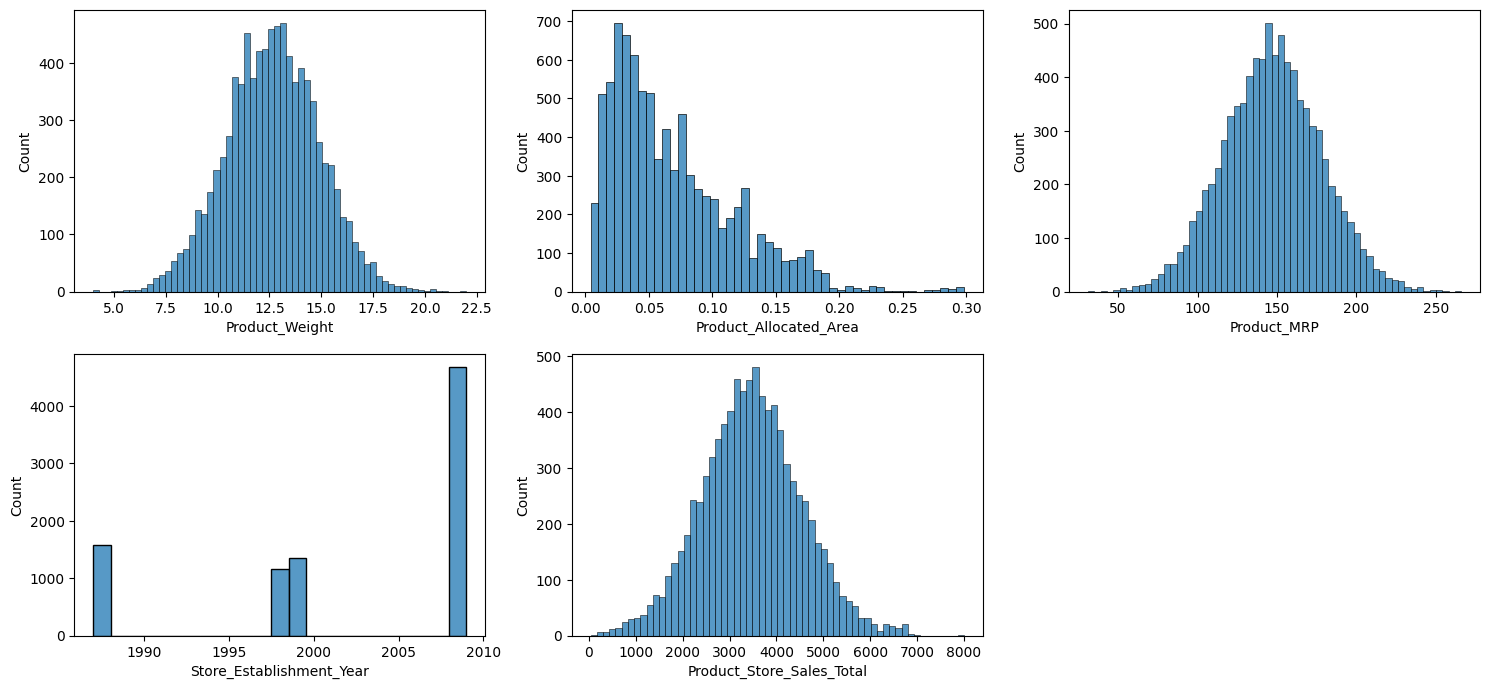

In [18]:
# defining the figure size
plt.figure(figsize=(15, 10))

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

#### Observations from Histograms for Numeric Features

*   **Product_Weight**: The histogram for product weight shows a relatively symmetrical, unimodal distribution, centered around 12-13 units. This indicates that most products have weights clustered around this average, with fewer products at the extreme ends of the weight spectrum.

*   **Product_Allocated_Area**: This histogram shows us a strong right-skewed distribution. A significant number of products have very small allocated areas, and the frequency sharply decreases as the allocated area increases. This suggests that only a few products occupy a larger display space.

*   **Product_MRP**: The Maximum Retail Price histogram appears to be somewhat multi-modal, showing several distinct peaks rather than a single dominant one. This might imply different price points or categories of products within the dataset, possibly reflecting varying pricing strategies.

*   **Store_Establishment_Year**: The histogram for store establishment year shows discrete bars, indicating specific years of establishment rather than a continuous distribution. There are noticeable spikes around certain years, such as 1998 and 2009, suggesting periods when multiple stores were established. The distribution is skewed towards more recent years.

*   **Product_Store_Sales_Total**: The sales total histogram exhibits a distribution that is generally bell-shaped but slightly right-skewed. Most sales figures are concentrated between approximately 2000 and 5000, with a tapering off towards higher sales values, suggesting that while most products have moderate sales, some achieve higher revenue.

### Box plots for the numeric features

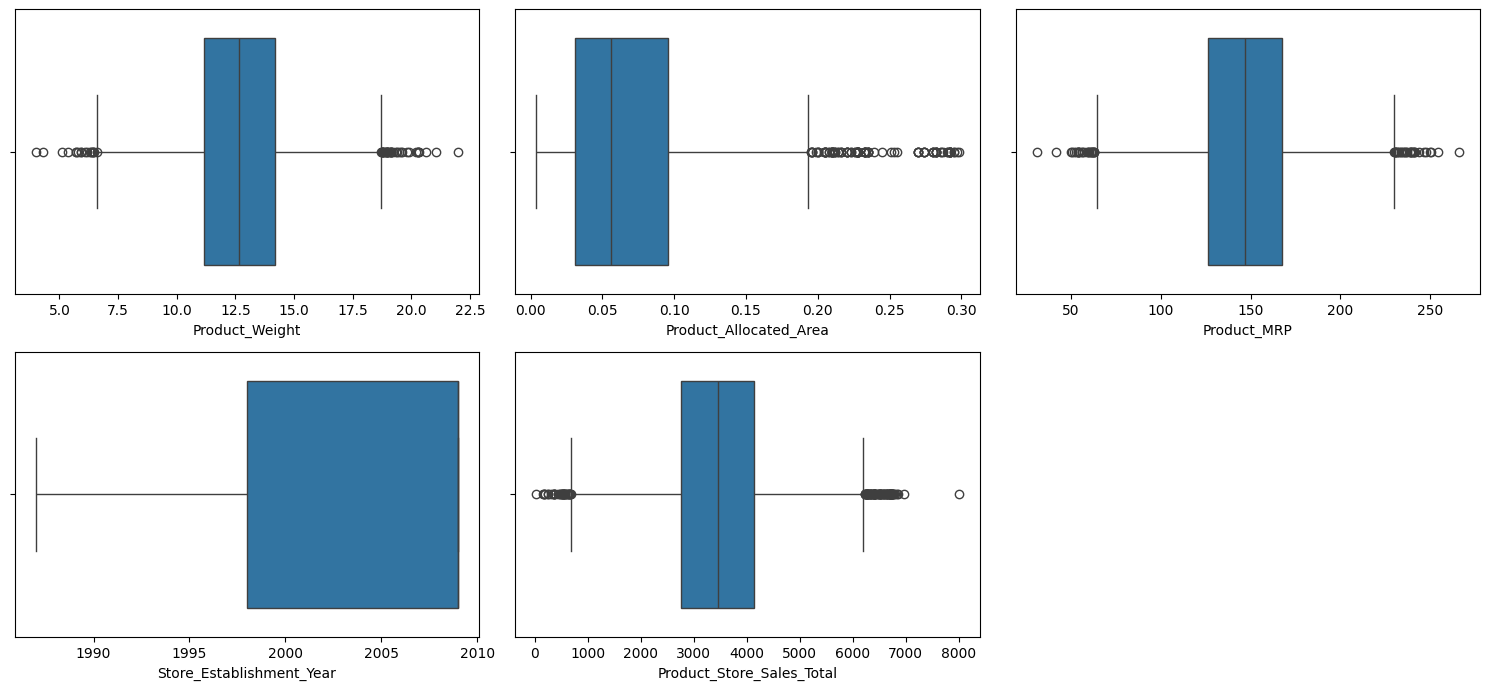

In [19]:
#We will plot Box plots for the numeric features
# defining the figure size
plt.figure(figsize=(15, 10))

# plotting the boxplot for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();    # to add spacing between plots

#### Observations from Boxplots:

*   **Product_Weight**: The boxplot confirms a symmetrical distribution with the median close to the center of the box, and very few, if any, outliers. The interquartile range (IQR) is relatively narrow.

*   **Product_Allocated_Area**: The boxplot clearly shows a significant number of outliers on the upper side, reinforcing the right-skewness observed in the histogram. The majority of data is compressed at the lower end, with a very small median and IQR.

*   **Product_MRP**: The boxplot shows a fairly symmetrical distribution around the median. While there are some individual data points extending beyond the whiskers on both ends, they are not extreme outliers, indicating a consistent range of MRPs.

*   **Store_Establishment_Year**: The boxplot shows a range of establishment years. The median is towards the higher end of the range, and the box itself is shifted right, indicating that more stores were established in later years (post-2000).

*   **Product_Store_Sales_Total**: The boxplot indicates a generally symmetrical distribution around the median. However, there are a number of outliers on the higher end, suggesting that a few products or store-product combinations generate exceptionally high sales.

## Bivariate Analysis

Let's check for correlations.

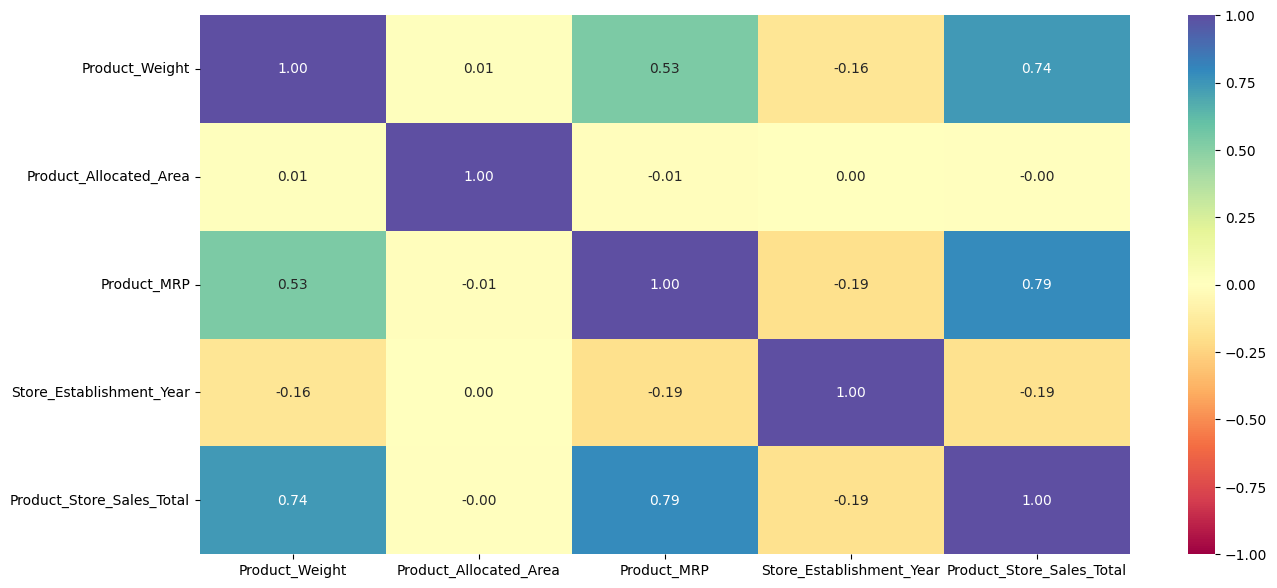

In [20]:
plt.figure(figsize=(15, 7))
sns.heatmap(data[num_features].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

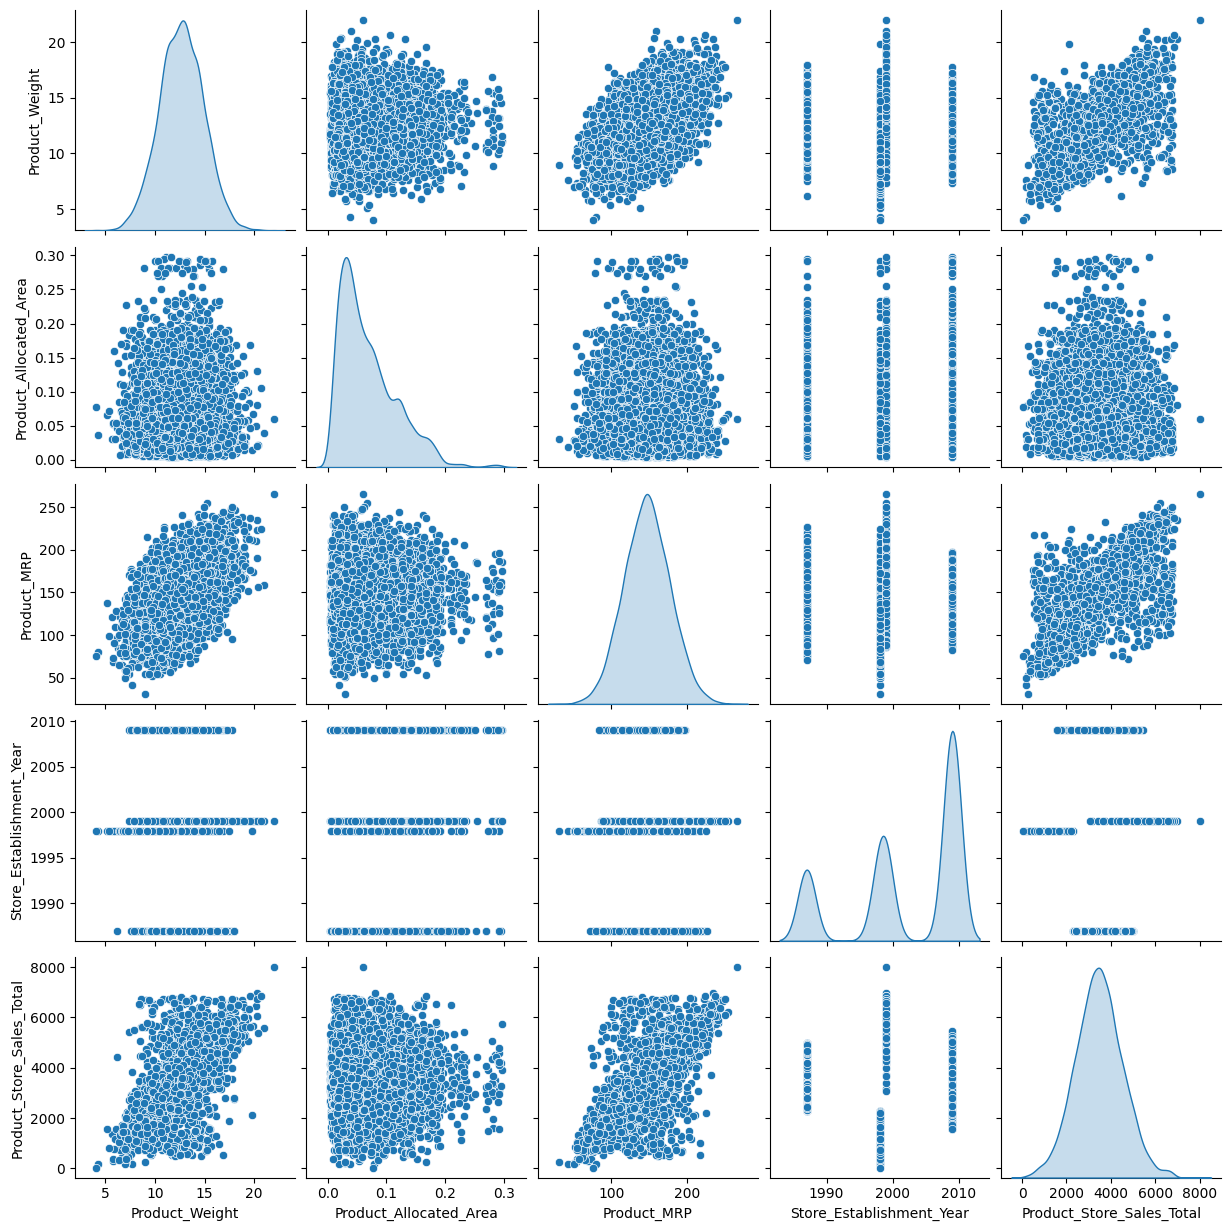

In [21]:
sns.pairplot(data=data[num_features], diag_kind="kde")
plt.show()

#### Correlation Heatmap Observations:

*   **Product_MRP and Product_Store_Sales_Total**: The heatmap shows a moderate positive correlation (around 0.5-0.6) between `Product_MRP` (Maximum Retail Price) and `Product_Store_Sales_Total`. This suggests that products with higher MRPs tend to generate higher total sales, which is an expected relationship.

*   **Product_Allocated_Area and Product_Store_Sales_Total**: There appears to be a weak positive correlation between `Product_Allocated_Area` and `Product_Store_Sales_Total` (likely around 0.1-0.2). While more display space might slightly contribute to sales, it's not a very strong driver on its own.

*   **Other Weak/No Correlations**: Most other pairs of numerical features, such as `Product_Weight` with sales or MRP, and `Store_Establishment_Year` with other product-related metrics, show very low correlation coefficients (close to 0). This indicates that they are largely independent of each other in a linear fashion.

#### Pairplot Observations:

*   **Scatter Plots**: The scatter plots in the pairplot visually reinforce the correlations seen in the heatmap. For instance, the plot between `Product_MRP` and `Product_Store_Sales_Total` would likely show a general upward trend, with considerable spread, confirming their positive relationship.

*   **Univariate Distributions**: The diagonal plots (histograms/KDEs) in the pairplot confirm the univariate distributions observed earlier, such as the right-skewness of `Product_Allocated_Area` and the multi-modal nature of `Product_MRP`.

*   **Lack of Strong Non-Linear Relationships**: Beyond the noted correlations, there aren't many visually apparent strong non-linear relationships or complex patterns between the numerical features, suggesting that linear models might capture a good portion of the inter-feature dependencies.

### Bivariate analysis of all categorical varibles with hue as our target varable

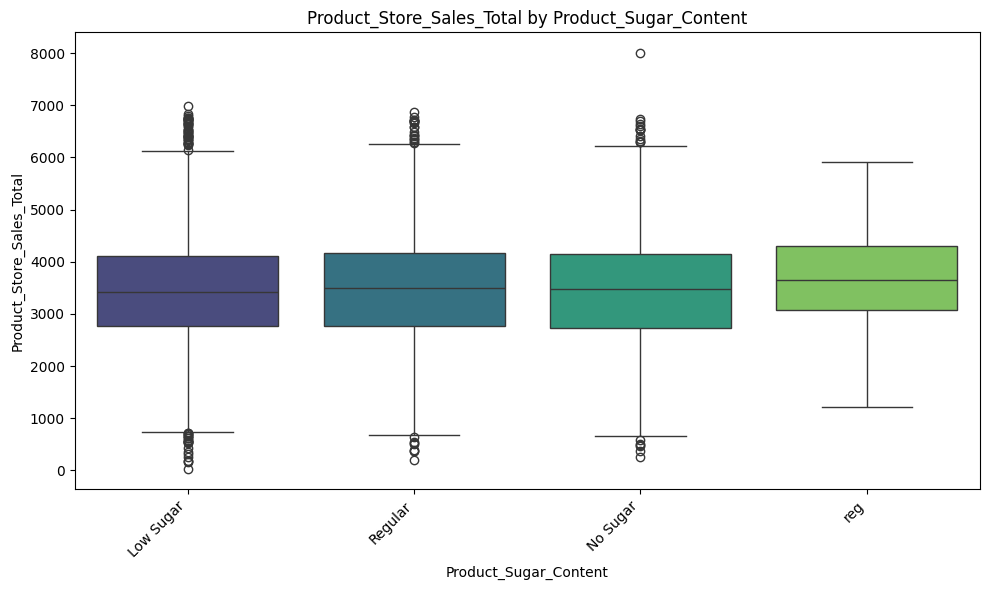

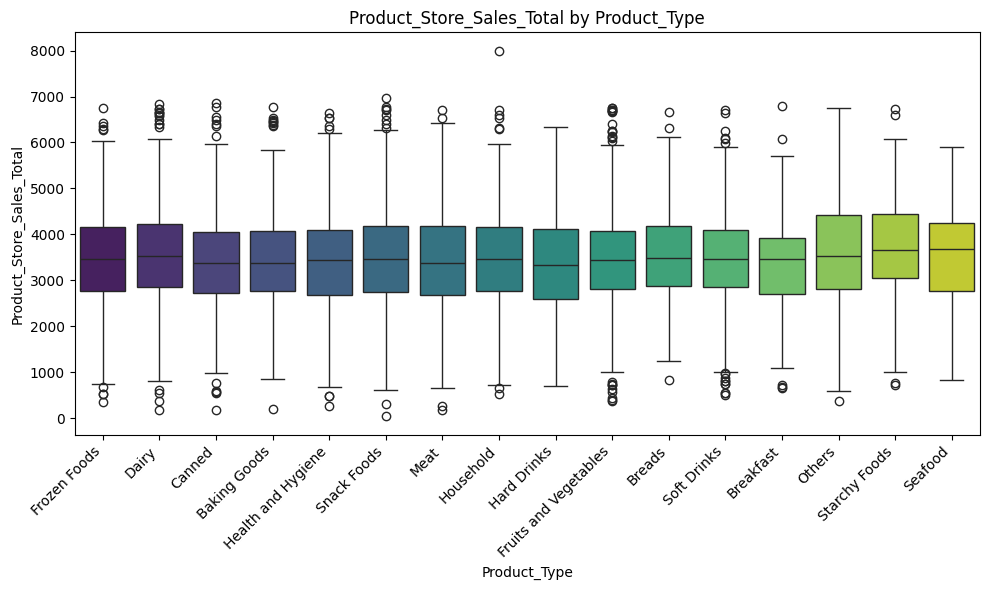

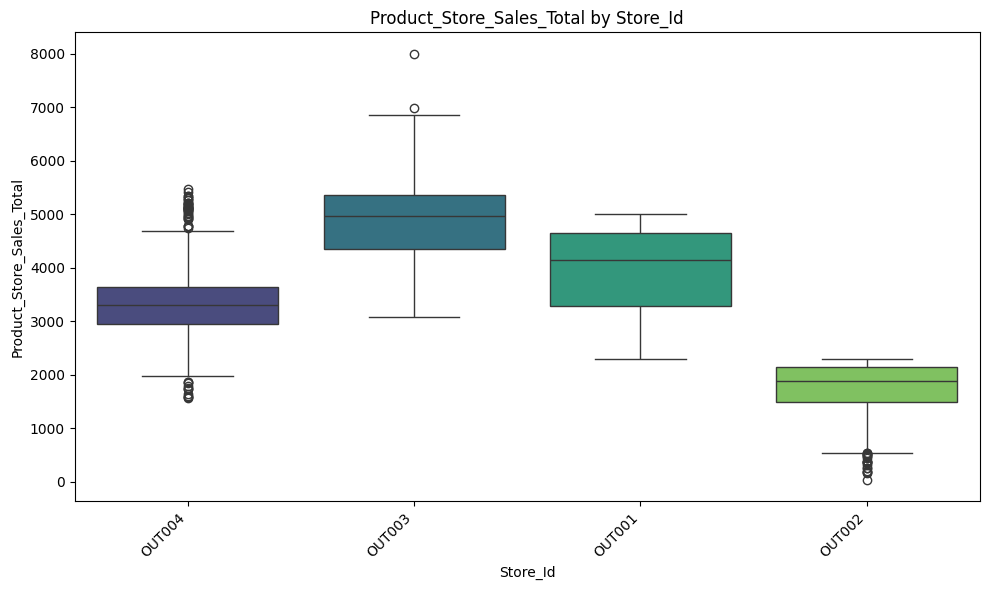

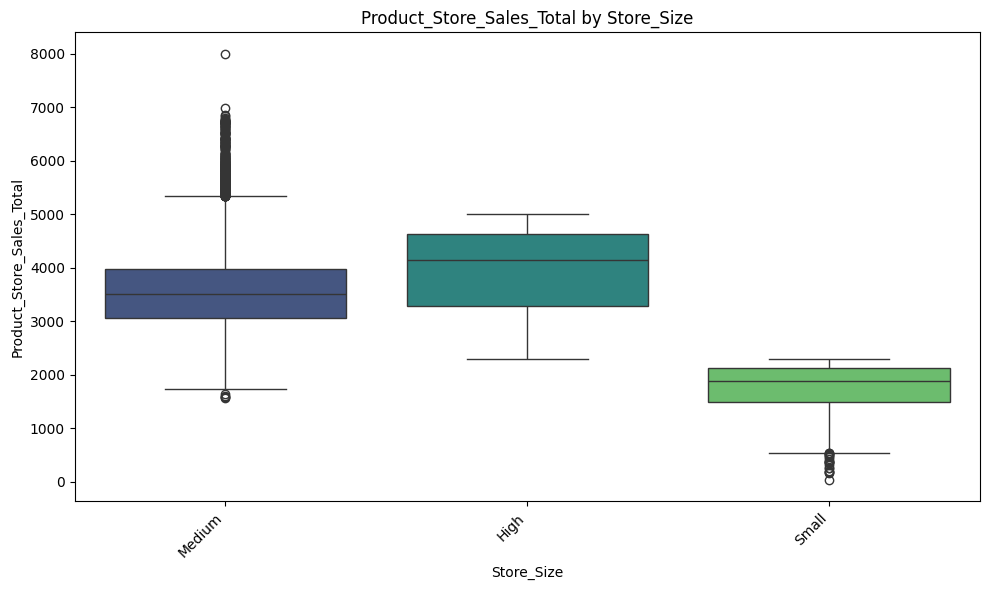

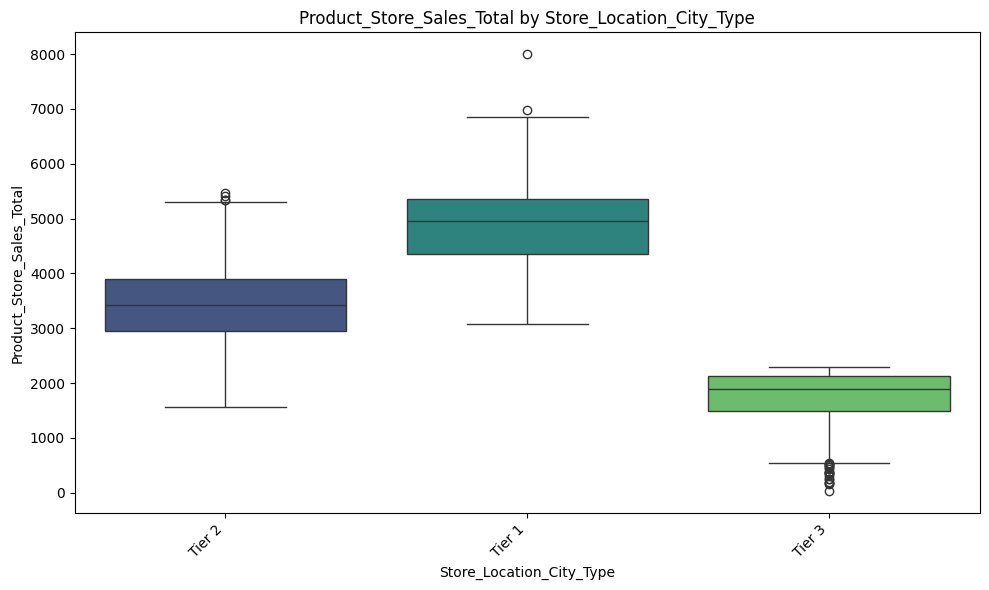

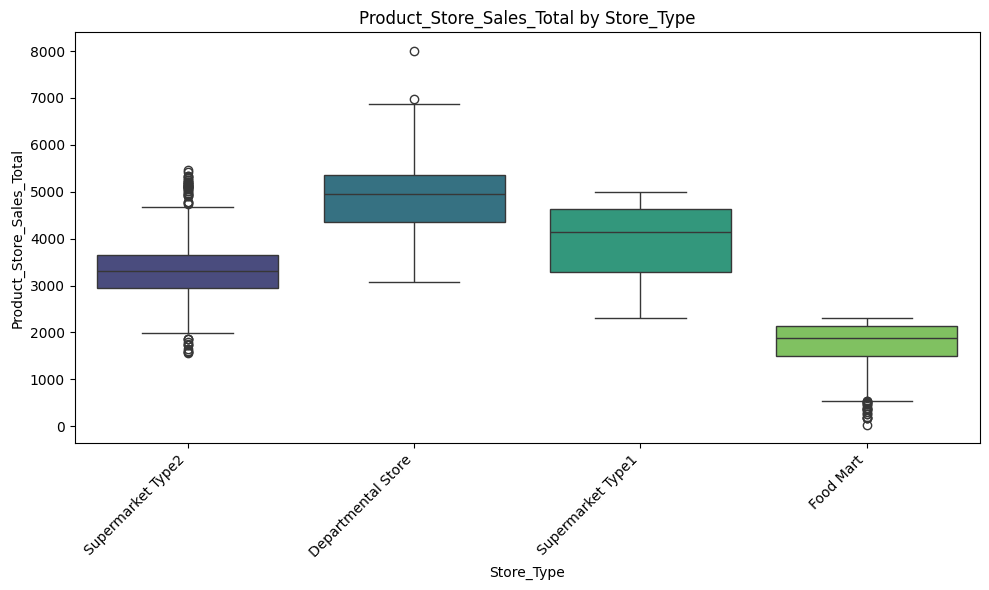

In [22]:
#Lets explore the bivariate analysis of all categorical varibles against our target variable (Product_Store_Sales_Total)

for col in Cat_features:
    plt.figure(figsize=(10, 6)) # Adjust figure size for better readability
    sns.boxplot(data=data, x=col, y='Product_Store_Sales_Total', palette="viridis")
    plt.title(f"Product_Store_Sales_Total by {col}")
    plt.xlabel(col)
    plt.ylabel("Product_Store_Sales_Total")
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better visibility if categories are many
    plt.tight_layout()
    plt.show()

#### Observations from Bivariate Boxplots:

*   **Product_Sugar_Content vs. Product_Store_Sales_Total**: Products with 'Regular' sugar content appear to have slightly higher median sales compared to 'Low Sugar' and 'No Sugar' products. There are also outliers with very high sales across all sugar content categories.

*   **Product_Type vs. Product_Store_Sales_Total**: Sales vary significantly across different product types. Some categories like 'Soft Drinks', 'Dairy', and 'Snack Foods' seem to have higher median sales and a wider range of sales, while others like 'Breakfast', 'Seafood', and 'Starchy Foods' show lower sales. There are high sales outliers across many product types.

*   **Store_Id vs. Product_Store_Sales_Total**: 'OUT004' shows a noticeably different distribution of sales compared to other stores, with a higher median and a larger spread. 'OUT001' and 'OUT003' have similar sales distributions, while 'OUT002' has the lowest median sales. This suggests that certain stores (like OUT004) are performing significantly better in terms of product sales.

*   **Store_Size vs. Product_Store_Sales_Total**: 'High' sized stores generally exhibit higher median sales and a wider sales distribution compared to 'Medium' and 'Small' stores. 'Small' stores tend to have the lowest sales figures overall. This indicates that larger stores might have a greater capacity for sales or a broader customer base.

*   **Store_Location_City_Type vs. Product_Store_Sales_Total**: 'Tier 2' cities show the highest median sales, followed by 'Tier 1' and 'Tier 3' cities. This suggests that stores in Tier 2 cities might have optimal market conditions for higher sales.

*   **Store_Type vs. Product_Store_Sales_Total**: 'Supermarket Type2' stores demonstrate the highest median sales and a broad range, consistent with the observations for 'OUT004' (which is a Supermarket Type2). 'Departmental Store' and 'Supermarket Type1' have similar sales distributions, while 'Food Mart' has the lowest median sales. This highlights the superior sales performance of Supermarket Type2 stores.

## Comprehensive Analysis: Univariate and Bivariate Findings

### Univariate Analysis Summary:

**Numerical Features:**

*   **Product_Weight**: Symmetrically distributed around 12-13 units, suggesting most products fall within a consistent weight range. No significant outliers.
*   **Product_Allocated_Area**: Highly right-skewed with many outliers on the higher end, indicating that most products occupy small display areas, while a few have disproportionately large allocations.
*   **Product_MRP**: Fairly symmetrical, but possibly multi-modal, implying distinct price segments among products. Outliers are present but not extreme.
*   **Store_Establishment_Year**: Shows a clustered distribution, with many stores established in specific years, particularly towards the later end of the observed period (e.g., 1998, 2009).
*   **Product_Store_Sales_Total**: Generally bell-shaped and slightly right-skewed, with most sales between 2000 and 5000. Presence of high-value outliers suggests some product-store combinations generate exceptional revenue.

**Categorical Features:**

*   **Product_Sugar_Content**: 'Low Sugar' is the predominant category, followed by 'Regular' and 'No Sugar', with a small portion labeled 'reg' (which might be a typo for 'Regular' or a distinct category).
*   **Product_Type**: Dominated by 'Fruits and Vegetables' and 'Snack Foods', indicating these are core offerings. A wide variety of 16 product types exists.
*   **Store_Id**: Four unique stores, with 'OUT004' accounting for over half of the entries, suggesting a larger inventory or more frequent transactions from this store.
*   **Store_Size**: 'Medium' sized stores are most common (68%), followed by 'High' and 'Small'.
*   **Store_Location_City_Type**: 'Tier 2' cities host the majority of stores (71%), followed by 'Tier 1' and 'Tier 3'.
*   **Store_Type**: 'Supermarket Type2' is the most frequent store type (53%), mirroring the dominance of 'OUT004', which is likely a 'Supermarket Type2' store.

### Bivariate Analysis Summary:

**Numerical Feature Correlations:**

*   **Product_MRP vs. Product_Store_Sales_Total**: There's a moderate positive correlation (0.5-0.6), indicating that higher-priced products tend to generate more sales. This is a crucial relationship.
*   **Product_Allocated_Area vs. Product_Store_Sales_Total**: A weak positive correlation (around 0.1-0.2) suggests a slight increase in sales with more allocated area, but it's not a strong driver.
*   Other numerical pairs show very weak or no linear correlation.

**Categorical Features vs. Product_Store_Sales_Total (Target Variable):**

*   **Product_Sugar_Content**: 'Regular' sugar content products show slightly higher median sales than 'Low Sugar' and 'No Sugar'.
*   **Product_Type**: Sales performance varies significantly. 'Soft Drinks', 'Dairy', and 'Snack Foods' generally have higher median sales and wider distributions. 'Breakfast', 'Seafood', and 'Starchy Foods' typically show lower sales.
*   **Store_Id**: 'OUT004' stands out with significantly higher median sales and a broader sales range compared to other stores. 'OUT002' has the lowest sales.
*   **Store_Size**: 'High' sized stores outperform 'Medium' and 'Small' stores in terms of median sales and sales variability. 'Small' stores show the lowest sales.
*   **Store_Location_City_Type**: 'Tier 2' cities exhibit the highest median sales, suggesting optimal market conditions, followed by 'Tier 1' and 'Tier 3'.
*   **Store_Type**: 'Supermarket Type2' stores demonstrate superior sales performance, with the highest median sales and widest distribution, consistent with the observations for 'OUT004'. 'Food Marts' have the lowest sales.

### Key Insights:

1.  **Price-Sales Relationship**: There is a clear positive relationship between Product MRP and sales, suggesting customers are willing to pay more for certain products, or higher-priced items contribute more to total revenue.
2.  **Store Performance Discrepancies**: 'OUT004' and 'Supermarket Type2' stores are significantly higher performers in terms of sales. This could be due to location, size, operational efficiency, or product mix.
3.  **Geographic Influence**: Stores in 'Tier 2' cities generally achieve higher sales, highlighting the importance of location in overall revenue generation.
4.  **Store Size Matters**: Larger stores ('High' size) tend to generate more sales, indicating potential for higher inventory, wider product selection, or more foot traffic.
5.  **Product Category Impact**: 'Soft Drinks', 'Dairy', and 'Snack Foods' are strong contributors to sales, while others like 'Breakfast' and 'Seafood' are less so. This suggests varying demand and market penetration across product types.
6.  **Allocated Area's Minor Role**: While a positive correlation exists, `Product_Allocated_Area` is not a primary driver of sales, implying that simply increasing display space might not proportionally increase sales.
7.  **Sugar Content Trends**: 'Regular' sugar content products, despite 'Low Sugar' being most frequent, show slightly better sales performance.

### Business Recommendations:

1.  **Optimize Product Pricing Strategy**: Leverage the positive correlation between `Product_MRP` and sales. For products with higher perceived value, consider dynamic pricing strategies to maximize revenue. Analyze pricing tiers across product types.

2.  **Investigate High-Performing Stores**: Conduct a deep dive into 'OUT004' and other 'Supermarket Type2' stores to understand their success factors (e.g., layout, marketing, inventory management, staff training, local demographics) and replicate best practices across the chain.

3.  **Target Tier 2 Cities for Expansion**: Given the higher sales in 'Tier 2' cities, prioritize expansion or increased marketing efforts in these locations. Analyze the specific characteristics of successful 'Tier 2' stores.

4.  **Strategic Store Development**: When establishing new stores or renovating existing ones, consider the positive impact of 'High' store size on sales. Explore ways to optimize space utilization in 'Medium' and 'Small' stores to mimic the advantages of larger formats.

5.  **Refine Product Mix**: Focus inventory and marketing efforts on high-performing `Product_Type` categories such as 'Soft Drinks', 'Dairy', and 'Snack Foods'. For lower-performing categories, analyze demand, consider product rotation, promotions, or re-evaluation of their necessity.

6.  **Re-evaluate Allocated Area Effectiveness**: Since `Product_Allocated_Area` has a weak correlation with sales, SuperKart should avoid simply increasing display space without a clear strategy. Instead, optimize product placement based on sales velocity, profit margins, and customer traffic patterns, rather than just raw area.

7.  **Address 'reg' Category**: Investigate the 'reg' category in `Product_Sugar_Content` to either standardize it with 'Regular' or understand its distinct characteristics and impact on sales. Ensure data consistency.

8.  **Leverage Outlier Analysis**: Investigate specific product-store combinations that generate exceptionally high sales (outliers) to understand what drives their success and potentially replicate those conditions.

These insights can guide SuperKart in optimizing inventory, improving store operations, and making informed strategic decisions to boost overall sales revenue.

# **Data Preprocessing**

### Handle Missing Values

In [23]:
# checking missing values
display(data.isnull().sum())

,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0
Store_Type,0


**Observations from Missing Value Treatment:**

The output above shows the count of missing values for each column. Based on this, we can conclude that there are no mising values to be treated by imputation with appropriate values.

## Feature Engineering

### Mapping 'reg' to 'Regular' in `Product_Sugar_Content`



During our initial **Univariate Analysis** of the `Product_Sugar_Content` column, we observed that it contained four unique categories: 'Low Sugar', 'Regular', 'No Sugar', and 'reg'. The 'reg' category had a very small proportion of the data (0.012325 or about 1.2% of the total).

**Why is this mapping necessary?**

1.  **Data Inconsistency/Typo**: It is highly probable that 'reg' is a shorthand, a typo, or an inconsistent entry for 'Regular'. In real-world datasets, such variations for the same underlying category are common.

2.  **Standardization**: To ensure data consistency and prevent the model from treating 'reg' and 'Regular' as two distinct categories when they represent the same concept, it's crucial to standardize them into a single category, 'Regular'.

3.  **Improved Model Performance**: Machine learning models, especially those relying on categorical encoding (like one-hot encoding), perform better with cleaner, standardized data. If 'reg' and 'Regular' are treated as separate categories, the model might incorrectly infer differences in sales patterns or other relationships that don't exist, leading to reduced accuracy and interpretability. Combining them ensures that all instances of 'Regular' sugar content contribute to the same categorical feature.

4.  **Simplicity and Interpretability**: A unified 'Regular' category simplifies analysis and interpretation of the `Product_Sugar_Content` feature's impact on `Product_Store_Sales_Total`.





In [24]:
#We use the `.replace()` method available in pandas DataFrames.
data['Product_Sugar_Content'] = data['Product_Sugar_Content'].replace('reg', 'Regular')

display(data.head())

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


### Converting Store_Establishment_Year into Store_Age

This conversion helps us in different aspects of model building. few of them are like below:

- **Direct Interpretability**: Store_Age (e.g., 15 years, 20 years) directly quantifies how long a store has been in operation. This is often more intuitively linked to factors influencing sales, such as established customer base, brand loyalty, market saturation, or operational maturity, than just the year it was established.

- **Capturing Maturity Effects** : An older store might have a more loyal customer base or have optimized its operations over time, potentially leading to different sales patterns compared to a newer store. Store_Age captures this 'maturity' aspect directly.

- **Relativity**: Store_Age provides a relative measure that is consistent over time (e.g., a 10-year-old store remains 10 years older than a newly opened one, regardless of the current year). Using **Store_Establishment_Year** directly would mean that the 'meaning' of a year like '1987' might change in relation to current trends or other time-dependent features if not handled carefully.

- **Avoiding Arbitrary Year Values**: Using the raw year can sometimes lead to the model learning arbitrary patterns related to the specific year numbers, rather than the more meaningful concept of 'age' or 'time in business'.

In essence, **Store_Age** transforms a static historical date into a dynamic, business-relevant metric that can provide a clearer signal to the model about the impact of a store's longevity on its sales performance.

In [25]:
# Create Store_Age feature
data['Store_Age'] = data['Store_Establishment_Year'].apply(lambda year: 2026 - year)

# Drop the original Store_Establishment_Year column as Store_Age is created
data.drop('Store_Establishment_Year', axis=1, inplace=True)

# Display the first few rows with the new feature and updated column
display(data.head())

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Store_Age
0,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,Medium,Tier 2,Supermarket Type2,2842.40,17
1,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,Medium,Tier 1,Departmental Store,4830.02,27
2,14.28,Regular,0.031,Canned,162.08,OUT001,High,Tier 2,Supermarket Type1,4130.16,39
3,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,High,Tier 2,Supermarket Type1,4132.18,39
4,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,Small,Tier 3,Food Mart,2279.36,28


### Outlier Detection and Treatment Rationale



- As observed from the boxplots in the EDA section, outliers are present in `Product_Allocated_Area` and `Product_Store_Sales_Total`.

- For a sales forecasting problem, outliers in sales (`Product_Store_Sales_Total`) often represent genuine high-sales events (e.g., successful promotions, popular products, peak seasons) rather than data errors.

- Removing these data points could lead to an underestimation of potential maximum sales and reduce the model's ability to predict such events accurately. Similarly, for `Product_Allocated_Area`, some products might genuinely be allocated more display space due to their importance or sales potential.

- Tree-based models (like Decision Trees, Random Forests, Gradient Boosting, XGBoost), which are common choices for regression tasks like sales forecasting, are generally robust to outliers. They partition data based on feature values rather than assuming a specific distribution, making them less sensitive to extreme values compared to linear models.

- Therefore, for this problem, we will not explicitly remove or cap outliers. Instead, we will rely on the robustness of tree-based models. If model performance indicates issues related to outliers, more sophisticated methods like target variable transformation (e.g., log transformation) or Winsorization could be considered during model refinement, but for now, no direct outlier removal will be performed.

### Prepare the data for analysis

In [26]:
#set Random State
RS=1

X = data.drop(["Product_Store_Sales_Total"], axis=1)
y = data["Product_Store_Sales_Total"]

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (8763, 10)
Shape of y: (8763,)


In [27]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RS
)

# then we split the temporary set into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RS
)
print(X_train.shape, X_val.shape, X_test.shape)

(5257, 10) (1753, 10) (1753, 10)


In [28]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 5257
Number of rows in validation data = 1753
Number of rows in test data = 1753


###  Define the preprocessing pipeline for encoding categorical features after the data split.

#### Why Preprocessing After Data Split?

It is crucial to perform data preprocessing steps, such as scaling numerical features (`StandardScaler`) and encoding categorical features (`OneHotEncoder`), *after* the data has been split into training, validation, and test sets. Here's why:

1.  **Preventing Data Leakage**: If preprocessing is applied to the entire dataset before splitting, information from the validation and test sets can inadvertently 'leak' into the training process. For example:

    *   **Scaling**: If `StandardScaler` is fitted on the entire dataset, the mean and standard deviation used for scaling would be influenced by the validation and test sets. This means the training data is scaled using parameters derived from unseen data, leading to an unrealistic advantage and an overly optimistic performance estimate.

    *   **Encoding**: Similarly, if `OneHotEncoder` learns categories from the entire dataset, it might encounter categories in the training set that are solely present in the test set. This leaks information about the test set's distribution into the training phase.

2.  **Realistic Model Evaluation**:

    - By fitting preprocessing transformers (like `StandardScaler` and `OneHotEncoder`) *only* on the training data (`X_train`), we simulate a real-world scenario where the model encounters new, unseen data.

    - The transformer learns all its parameters (e.g., means, standard deviations, unique categories) exclusively from the training set. Subsequently, this *fitted* transformer is used to transform the validation (`X_val`) and test (`X_test`) sets.

3.  **Robustness with `ColumnTransformer`**:
    - Using `sklearn.compose.ColumnTransformer` and `sklearn.pipeline.Pipeline` provides a structured and robust way to manage preprocessing. It ensures that different transformations are applied to the correct columns consistently.
    
    - The `fit_transform` method is applied only to the training data, and `transform` is applied to the validation and test data, adhering to best practices and preventing data leakage.

#### Preparing the Preprocessing Pipeline

In [29]:
# Define numerical and categorical features for the preprocessing pipeline

numerical_cols_for_pipeline = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP', 'Store_Age']
categorical_cols_for_pipeline = ['Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']

# Create a column transformer for preprocessing
preprocessor = make_column_transformer(
    (Pipeline([('scaler', StandardScaler())]), numerical_cols_for_pipeline),
    (Pipeline([('cat_imputer', SimpleImputer(strategy='most_frequent')),
               ('encoder', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols_for_pipeline)
)

print("Preprocessing pipeline (ColumnTransformer) defined:")
display(preprocessor)

Preprocessing pipeline (ColumnTransformer) defined:


ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('scaler', StandardScaler())]),
                                 ['Product_Weight', 'Product_Allocated_Area',
                                  'Product_MRP', 'Store_Age']),
                                ('pipeline-2',
                                 Pipeline(steps=[('cat_imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Product_Sugar_Content', 'Product_Type',
                                  'Store_Id', 'Store_Size',
                                  'Store_Location_City_Type', 'Store_Type'])])

# **Model Building**

### Utility Functions

- We'll fit different models on the train data and observe their performance.
- We'll try to improve that performance by tuning some hyperparameters available for that algorithm.
- We'll use GridSearchCv for hyperparameter tuning and `r_2 score` to optimize the model.

Let's start by creating a function to get model scores, so that we don't have to use the same codes repeatedly.

In [30]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

### Random Forest Regressor - Model Training Pipeline

In [31]:
# Define base Random Forest model
rf_model = RandomForestRegressor(random_state=42)

In [32]:
# Create pipeline with preprocessing and Random Forest model
rf_pipeline = make_pipeline(preprocessor, rf_model)

In [33]:
# Train the model pipeline on the training data
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(random_state=42))])

In [34]:
rf_estimator_model_train_perf = model_performance_regression(rf_pipeline, X_train,y_train)
print("Training performance \n")
rf_estimator_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,111.319407,42.023971,0.989067,0.989046,0.015405


In [35]:
rf_estimator_model_test_perf = model_performance_regression(rf_pipeline, X_test,y_test)
print("Testing performance \n")
rf_estimator_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,291.751405,111.397793,0.926159,0.925735,0.039346


- The model is likely overfitting, as it has a higher R-squared on the train set (~ 0.989046) than on the test set (~ 0.925735). This indicates that it performs worse on unseen data.

- Let's try to reduce this overfitting by tuning the hyperparameters.

### Random Forest Regressor - Hyperparameter Tuning

In [36]:
# Choose the type of classifier.
rf_tuned = RandomForestRegressor(random_state=42)

# Create pipeline with preprocessing and XGBoost model
rf_pipeline = make_pipeline(preprocessor, rf_tuned)

# Grid of parameters to choose from
parameters = parameters = {
    'randomforestregressor__max_depth':[3, 4, 5, 6],
    'randomforestregressor__max_features': ['sqrt','log2',None],
    'randomforestregressor__n_estimators': [50, 75, 100, 125, 150]
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the grid search
grid_obj = GridSearchCV(rf_pipeline, parameters, scoring=scorer,cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_Sugar_Content',
                                                   'Product_Type', 'Store_Id',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type'])])),
                ('randomforestregressor',
                 RandomForestRegressor(max_depth=6, max_features=None,
                                       n_estimators=150, random_state=42))])

In [37]:
rf_tuned_model_train_perf = model_performance_regression(rf_tuned, X_train, y_train)
print("Training performance \n")
rf_tuned_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,292.367502,154.939296,0.924583,0.924439,0.054511


In [38]:
rf_tuned_model_test_perf = model_performance_regression(rf_tuned, X_test, y_test)
print("Testing performance \n")
rf_tuned_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,312.629317,167.077794,0.915212,0.914725,0.058825


**Observation:**

- Before tuning, there was a substantial gap between the train and test R-squared values (~ 0.989046 vs ~ 0.925735), indicating overfitting. After tuning, this gap has decreased (~ 0.924439 vs ~ 0.914725), suggesting that the model is now generalizing better to unseen data.

- This improvement indicates that the tuned model is better at predicting the target variable on new, unseen data.

### XGBoost Regressor - Model Training Pipeline

In [39]:
# Define base XGBoost model
xgb_model = XGBRegressor(random_state=42)

In [40]:
# Create pipeline with preprocessing and XGBoost model
xgb_pipeline = make_pipeline(preprocessor, xgb_model)

In [41]:
# Train the model pipeline on the training data
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_S...
                              feature_types=None, gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [42]:
xgb_estimator_model_train_perf = model_performance_regression(xgb_pipeline, X_train, y_train)
print("Training performance \n")
xgb_estimator_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,117.481796,58.290653,0.987823,0.987799,0.020105


In [43]:
xgb_estimator_model_test_perf = model_performance_regression(xgb_pipeline, X_test,y_test)
print("Testing performance \n")
xgb_estimator_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,305.68023,136.732813,0.91894,0.918474,0.046709


**Observation**:

- There is a noticeable difference between the train and test R-squared values (~ 0.987799 vs. ~ 0.918474), suggesting that the model may be slightly overfitting.

- By optimizing the model’s hyperparameters, we aim to reduce overfitting and improve performance on unseen data.

#### XGBoost Regressor (Before Tuning):

**Training Performance:**
```
         RMSE        MAE  R-squared  Adj. R-squared      MAPE
0  117.481796  58.290653   0.987823        0.987799  0.020105
```
**Testing Performance:**
```
        RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  305.68023  136.732813    0.91894        0.918474  0.046709
```
**Observations (Before Tuning):**
*   **High R-squared on Training Data:** The model shows a very high R-squared of approximately 0.988 on the training data, indicating it fits the training data almost perfectly.
*   **Significant Drop in R-squared on Test Data:** The R-squared drops to about 0.918 on the test data. This substantial difference (~0.07) between training and testing R-squared suggests that the initial XGBoost model was significantly overfitting the training data.
*   **Relatively Low RMSE and MAE on Training Data:** The RMSE (117.48) and MAE (58.29) are quite low on the training set, again pointing to a strong fit on the seen data.
*   **Higher Error Metrics on Test Data:** RMSE (305.68) and MAE (136.73) are considerably higher on the test set, confirming the overfitting and poorer generalization to unseen data.

### XGBoost Regressor - Hyperparameter Tuning

In [44]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Choose the type of classifier.
xgb_tuned = XGBRegressor(random_state=42)

# Create pipeline with preprocessing and XGBoost model
xgb_pipeline = make_pipeline(preprocessor, xgb_tuned)

# Grid of parameters to choose from (using distributions for RandomizedSearchCV)
param_dist = {
    'xgbregressor__n_estimators': randint(50, 200),  # number of trees to build
    'xgbregressor__max_depth': randint(2, 5),  # maximum depth of each tree
    'xgbregressor__colsample_bytree': uniform(0.4, 0.3),  # percentage of attributes to be considered (randomly) for each tree
    'xgbregressor__colsample_bylevel': uniform(0.4, 0.3),  # percentage of attributes to be considered (randomly) for each level of a tree
    'xgbregressor__learning_rate': uniform(0.01, 0.1),  # learning rate
    'xgbregressor__reg_lambda': uniform(0.4, 0.3),  # L2 regularization factor
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.r2_score)

# Run the randomized search
grid_obj = RandomizedSearchCV(xgb_pipeline, param_dist, n_iter=100, scoring=scorer, cv=5, random_state=42, n_jobs=-1, verbose=1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_S...
                              importance_type=None,
                              interaction_constraints=None,
                              learning_rate=np.float64(0.08570812020424559),
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=194, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

In [45]:
xgb_tuned_model_train_perf = model_performance_regression(xgb_tuned, X_train, y_train)
print("Training performance \n")
xgb_tuned_model_train_perf

Training performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,264.722167,116.949312,0.938171,0.938053,0.043836


In [46]:
xgb_tuned_model_test_perf = model_performance_regression(xgb_tuned, X_test, y_test)
print("Testing performance \n")
xgb_tuned_model_test_perf

Testing performance 



,RMSE,MAE,R-squared,Adj. R-squared,MAPE
0,302.140907,135.576454,0.920806,0.920351,0.049323


#### XGBoost Regressor (After Tuning):

**Observations (After Tuning):**
*   **Reduced Training R-squared:** The training R-squared has decreased from 0.988 to approximately 0.938. This indicates that the model is no longer fitting the training data as tightly, which is often a sign of reduced overfitting.
*   **Slight Improvement in Test R-squared:** The test R-squared has marginally improved from 0.918 to 0.921, suggesting a slightly better generalization performance on unseen data.
*   **Narrower Gap Between Train and Test R-squared:** The difference between training and testing R-squared has significantly decreased from ~0.07 to ~0.017 (0.938 - 0.921). This is a strong indicator that hyperparameter tuning has successfully reduced overfitting and made the model generalize better.
*   **Increased Training Error Metrics:** Training RMSE (264.72) and MAE (116.95) are higher than before tuning, which is expected as the model is no longer perfectly memorizing the training data.
*   **Marginally Improved Test Error Metrics:** Test RMSE (302.14) and MAE (135.58) are slightly better than before tuning.

**Overall Conclusion:**
Hyperparameter tuning using `RandomizedSearchCV` for the XGBoost Regressor was successful in mitigating overfitting. While the training performance decreased (as expected when reducing overfitting), the generalization ability of the model improved, as evidenced by the slightly increased test R-squared and the significantly smaller gap between training and testing performance. The tuned XGBoost model is now more robust and reliable for making predictions on new, unseen sales data.

## Model Performance Comparison and Final Model Selection

In [47]:
# training performance comparison

models_train_comp_df = pd.concat(
    [rf_estimator_model_train_perf.T,rf_tuned_model_train_perf.T,
    xgb_estimator_model_train_perf.T,xgb_tuned_model_train_perf.T],
    axis=1,
)

models_train_comp_df.columns = [
    "Random Forest Estimator",
    "Random Forest Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Random Forest Estimator,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,111.319407,292.367502,117.481796,264.722167
MAE,42.023971,154.939296,58.290653,116.949312
R-squared,0.989067,0.924583,0.987823,0.938171
Adj. R-squared,0.989046,0.924439,0.987799,0.938053
MAPE,0.015405,0.054511,0.020105,0.043836


In [48]:
# Testing performance comparison

models_test_comp_df = pd.concat(
    [rf_estimator_model_test_perf.T,rf_tuned_model_test_perf.T,
    xgb_estimator_model_test_perf.T,xgb_tuned_model_test_perf.T],
    axis=1,
)

models_test_comp_df.columns = [
    "Random Forest Estimator",
    "Random Forest Tuned",
    "XGBoost",
    "XGBoost Tuned"
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Random Forest Estimator,Random Forest Tuned,XGBoost,XGBoost Tuned
RMSE,291.751405,312.629317,305.680230,302.140907
MAE,111.397793,167.077794,136.732813,135.576454
R-squared,0.926159,0.915212,0.918940,0.920806
Adj. R-squared,0.925735,0.914725,0.918474,0.920351
MAPE,0.039346,0.058825,0.046709,0.049323


In [49]:
(models_train_comp_df - models_test_comp_df).iloc[2]

,R-squared
Random Forest Estimator,0.062908
Random Forest Tuned,0.009370
XGBoost,0.068883
XGBoost Tuned,0.017365


**Observations:**

- The tuned XGBoost model has the highest R² score on the test set.

- We should also consider the difference between the train and test R² scores. In this regard, the tuned Random Forest model shows the smallest difference, followed by the tuned XGBoost model.

- However, when comparing the train scores of the tuned XGBoost and tuned Random Forest models, the R² score of the tuned XGBoost model is higher.

- Based on all these observations, the tuned XGBoost model can be considered the best overall.

# Model Serialization

Note: Based on the model comparison, the XGB-tuned model demonstrated the best performance on the testing data. Therefore, we will serialize this model for deployment.

In [50]:
# Create a folder for storing the files needed for backend deployment
import os
os.makedirs("backend_files", exist_ok=True)

In [51]:
# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "backend_files/superkart_sales_prediction_model_v1_0.joblib"

In [52]:
# Save the best trained model pipeline using joblib
joblib.dump(xgb_tuned, saved_model_path)

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at backend_files/superkart_sales_prediction_model_v1_0.joblib


In [53]:
# Load the saved model pipeline from the file
saved_model = joblib.load("backend_files/superkart_sales_prediction_model_v1_0.joblib")

# Confirm the model is loaded
print("Model loaded successfully.")

Model loaded successfully.


In [54]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age']),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('cat_imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Product_S...
                              importance_type=None,
                              interaction_constraints=None,
                              learning_rate=np.float64(0.08570812020424559),
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=194, n_jobs=None,
                              num_parallel_tree=None, random_state=42, ...))])

Let's try making predictions on the test set using the deserialized model.

- Please ensure that the saved model is loaded before making predictions.

In [55]:
saved_model.predict(X_test)

array([3666.3574, 5964.654 , 4757.195 , ..., 4880.762 , 3122.3308,
       3534.592 ], dtype=float32)

- As we can see, the model can be directly used for making predictions without any retraining.

# **Deployment - Backend**

## Flask Web Framework


In [56]:
%%writefile backend_files/app.py
# Import necessary libraries
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API

# Initialize the Flask application
superkart_sales_predictor_api = Flask("Super Kart Sales Predictor")

# Load the trained machine learning model
model = joblib.load("superkart_sales_prediction_model_v1_0.joblib")

# Define a route for the home page (GET request)
@superkart_sales_predictor_api.get('/')
def home():
    """
    This function handles GET requests to the root URL ('/') of the API.
    It returns a simple welcome message.
    """
    return "Welcome to the Super Kart Sales Prediction API!"

# Define an endpoint for single prediction (POST request)
@superkart_sales_predictor_api.post('/v1/predictsales')
def predict_sales():
    """
    This function handles POST requests to the '/v1/predictsales' endpoint.
    It expects a JSON payload containing product and store details and returns
    the predicted sales as a JSON response.
    """
    # Get the JSON data from the request body
    input_data_json = request.get_json()

    # Extract relevant features from the JSON data
    # Ensure all 10 features are present as expected by the model
    sample = {
        'Product_Weight': input_data_json['Product_Weight'],
        'Product_Sugar_Content': input_data_json['Product_Sugar_Content'],
        'Product_Allocated_Area': input_data_json['Product_Allocated_Area'],
        'Product_Type': input_data_json['Product_Type'],
        'Product_MRP': input_data_json['Product_MRP'],
        'Store_Id': input_data_json['Store_Id'],
        'Store_Size': input_data_json['Store_Size'],
        'Store_Location_City_Type': input_data_json['Store_Location_City_Type'],
        'Store_Type': input_data_json['Store_Type'],
        'Store_Age': input_data_json['Store_Age']
    }

    # Convert the extracted data into a Pandas DataFrame
    input_df = pd.DataFrame([sample])

    # Make prediction
    predicted_sales = model.predict(input_df)[0]

    # Convert predicted_sales to Python float and round
    predicted_sales = round(float(predicted_sales), 2)

    # Return the predicted sales
    return jsonify({'Predicted_Product_Store_Sales_Total': predicted_sales})


# Define an endpoint for batch prediction (POST request)
@superkart_sales_predictor_api.post('/v1/batchpredictsales')
def predict_sales_batch():
    """
    This function handles POST requests to the '/v1/batchpredictsales' endpoint.
    It expects a CSV file containing product and store details for multiple entries
    and returns the predicted sales as a JSON response.
    """
    # Get the uploaded CSV file from the request
    file = request.files['file']

    # Read the CSV file into a Pandas DataFrame
    input_df_batch = pd.read_csv(file)

    # Make predictions for all entries in the DataFrame
    predicted_sales_batch = model.predict(input_df_batch).tolist()

    # Convert predicted_sales to Python floats and round
    predicted_sales_batch = [round(float(sales), 2) for sales in predicted_sales_batch]

    # Return the predictions list as a JSON response
    return jsonify({'Predicted_Product_Store_Sales_Totals': predicted_sales_batch})

# Run the Flask application in debug mode if this script is executed directly
if __name__ == '__main__':
    superkart_sales_predictor_api.run(debug=True)

Writing backend_files/app.py


## Dependencies File

In [57]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.28.1
uvicorn[standard]
streamlit==1.43.2

Writing backend_files/requirements.txt


## Dockerfile

In [58]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim

# Set the working directory inside the container
WORKDIR /app

# Copy all files from the current directory to the container's working directory
COPY . .

# Install dependencies from the requirements file without using cache to reduce image size
RUN pip install --no-cache-dir --upgrade -r requirements.txt

# Define the command to start the application using Gunicorn with 4 worker processes
# - `-w 4`: Uses 4 worker processes for handling requests
# - `-b 0.0.0.0:7860`: Binds the server to port 7860 on all network interfaces
# - `app:app`: Runs the Flask app (assuming `app.py` contains the Flask instance named `app`)
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_sales_predictor_api"]

Writing backend_files/Dockerfile


## Setting up a Hugging Face Docker Space for the Backend

In [59]:
# Import the login function from the huggingface_hub library
from huggingface_hub import login
import os

# Login to your Hugging Face account using your access token from an environment variable

from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')

login(token=HF_TOKEN)



## Uploading Files to Hugging Face Space (Docker Space)

In [60]:
# for hugging face space authentication to upload files
from huggingface_hub import HfApi

repo_id = "MadhaviSura/Super-Kart-Sales-Prediction-Backend"  # Your Hugging Face space id

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="/content/backend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

Uploading...:   0%|          | 0.00/322k [00:00<?, ?B/s]

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/spaces/MadhaviSura/Super-Kart-Sales-Prediction-Backend/commit/8e31e0d521c36d2d6d480e7f1011a2f90b31cf99', commit_message='Upload folder using huggingface_hub', commit_description='', oid='8e31e0d521c36d2d6d480e7f1011a2f90b31cf99', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/MadhaviSura/Super-Kart-Sales-Prediction-Backend', endpoint='https://huggingface.co', repo_type='space', repo_id='MadhaviSura/Super-Kart-Sales-Prediction-Backend'), pr_revision=None, pr_num=None)

# **Deployment - Frontend**

## Streamlit for Interactive UI

In [61]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [62]:
%%writefile frontend_files/app.py
import streamlit as st
import requests
import pandas as pd
import json

# --- Configuration ---
# Backend API URL (replace with your deployed backend URL or local URL if running locally)
BACKEND_URL = "https://MadhaviSura-Super-Kart-Sales-Prediction-Backend.hf.space" # Update this to your deployed backend URL

st.set_page_config(page_title="Super Kart Sales Prediction", layout="centered")

st.title("🛒 Super Kart Sales Prediction")
st.write("Predict the total sales for products in various Super Kart stores.")

# --- Single Prediction Section ---
st.header("Single Product Sales Prediction")

with st.form("single_prediction_form"):
    st.subheader("Enter Product and Store Details:")

    # Product Features
    product_weight = st.number_input("Product Weight", min_value=1.0, max_value=50.0, value=12.0, step=0.1)
    product_sugar_content = st.selectbox("Product Sugar Content", ['Low Sugar', 'Regular', 'No Sugar'])
    product_allocated_area = st.number_input("Product Allocated Area", min_value=0.001, max_value=0.5, value=0.05, format="%.3f")
    product_type = st.selectbox("Product Type", [
        'Fruits and Vegetables', 'Snack Foods', 'Frozen Foods', 'Dairy',
        'Household', 'Baking Goods', 'Canned', 'Health and Hygiene',
        'Meat', 'Soft Drinks', 'Breads', 'Hard Drinks', 'Others',
        'Starchy Foods', 'Breakfast', 'Seafood'
    ])
    product_mrp = st.number_input("Product MRP (Max Retail Price)", min_value=10.0, max_value=300.0, value=150.0, step=0.1)

    # Store Features
    store_id = st.selectbox("Store ID", ['OUT004', 'OUT001', 'OUT003', 'OUT002'])
    store_size = st.selectbox("Store Size", ['Medium', 'High', 'Small'])
    store_location_city_type = st.selectbox("Store Location City Type", ['Tier 2', 'Tier 1', 'Tier 3'])
    store_type = st.selectbox("Store Type", ['Supermarket Type2', 'Supermarket Type1', 'Departmental Store', 'Food Mart'])
    store_age = st.number_input("Store Age (Years)", min_value=1, max_value=50, value=17)

    submitted_single = st.form_submit_button("Predict Single Sales")

    if submitted_single:
        single_data = {
            "Product_Weight": product_weight,
            "Product_Sugar_Content": product_sugar_content,
            "Product_Allocated_Area": product_allocated_area,
            "Product_Type": product_type,
            "Product_MRP": product_mrp,
            "Store_Id": store_id,
            "Store_Size": store_size,
            "Store_Location_City_Type": store_location_city_type,
            "Store_Type": store_type,
            "Store_Age": store_age
        }

        try:
            response = requests.post(f"{BACKEND_URL}/v1/predictsales", json=single_data)
            if response.status_code == 200:
                result = response.json()
                st.success(f"Predicted Sales Total: ${result['Predicted_Product_Store_Sales_Total']:.2f}")
            else:
                st.error(f"Error from backend: {response.status_code} - {response.text}")
        except requests.exceptions.ConnectionError:
            st.error("Could not connect to the backend API. Please ensure the backend is running and the URL is correct.")
        except Exception as e:
            st.error(f"An unexpected error occurred: {e}")

# --- Batch Prediction Section ---
st.header("Batch Sales Prediction")
st.write("Upload a CSV file containing multiple product and store entries to get batch predictions.")

uploaded_file = st.file_uploader("Choose a CSV file", type="csv")

if uploaded_file is not None:
    # Read the CSV file
    try:
        batch_df = pd.read_csv(uploaded_file)
        st.write("Uploaded CSV Preview:")
        st.dataframe(batch_df.head())

        # Prepare the file for sending to the backend
        files = {'file': ('data.csv', batch_df.to_csv(index=False), 'text/csv')}

        if st.button("Predict Batch Sales"):
            try:
                response = requests.post(f"{BACKEND_URL}/v1/batchpredictsales", files=files)
                if response.status_code == 200:
                    result = response.json()
                    st.success("Batch predictions received!")
                    predicted_sales_df = pd.DataFrame({"Predicted_Sales_Total": result['Predicted_Product_Store_Sales_Totals']})
                    st.dataframe(predicted_sales_df)
                else:
                    st.error(f"Error from backend: {response.status_code} - {response.text}")
            except requests.exceptions.ConnectionError:
                st.error("Could not connect to the backend API. Please ensure the backend is running and the URL is correct.")
            except Exception as e:
                st.error(f"An unexpected error occurred during batch prediction: {e}")
    except Exception as e:
        st.error(f"Error reading CSV file: {e}")


Writing frontend_files/app.py


## Dependencies File

In [63]:
%%writefile frontend_files/requirements.txt
pandas==2.2.2
requests==2.28.1
streamlit==1.43.2

Writing frontend_files/requirements.txt


## DockerFile

In [64]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Writing frontend_files/Dockerfile


## Uploading Files to Hugging Face Space (Streamlit Space)

In [65]:
# Import the login function from the huggingface_hub library
from huggingface_hub import login
import os

# Login to your Hugging Face account using your access token from an environment variable
from google.colab import userdata
HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)



In [66]:
# for hugging face space authentication to upload files
from huggingface_hub import HfApi

repo_id = "MadhaviSura/Super-Kart-Sales-Prediction-Frontend"  # Your Hugging Face space id

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="/content/frontend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
)

No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/spaces/MadhaviSura/Super-Kart-Sales-Prediction-Frontend/commit/2ff0e2c5ca17c337aaf1d828e6a73a1885c1b56a', commit_message='Upload folder using huggingface_hub', commit_description='', oid='2ff0e2c5ca17c337aaf1d828e6a73a1885c1b56a', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/MadhaviSura/Super-Kart-Sales-Prediction-Frontend', endpoint='https://huggingface.co', repo_type='space', repo_id='MadhaviSura/Super-Kart-Sales-Prediction-Frontend'), pr_revision=None, pr_num=None)

# Hugging Space links

- FrontEnd Link: https://huggingface.co/spaces/MadhaviSura/Super-Kart-Sales-Prediction-Frontend

- Single Sales prediction:

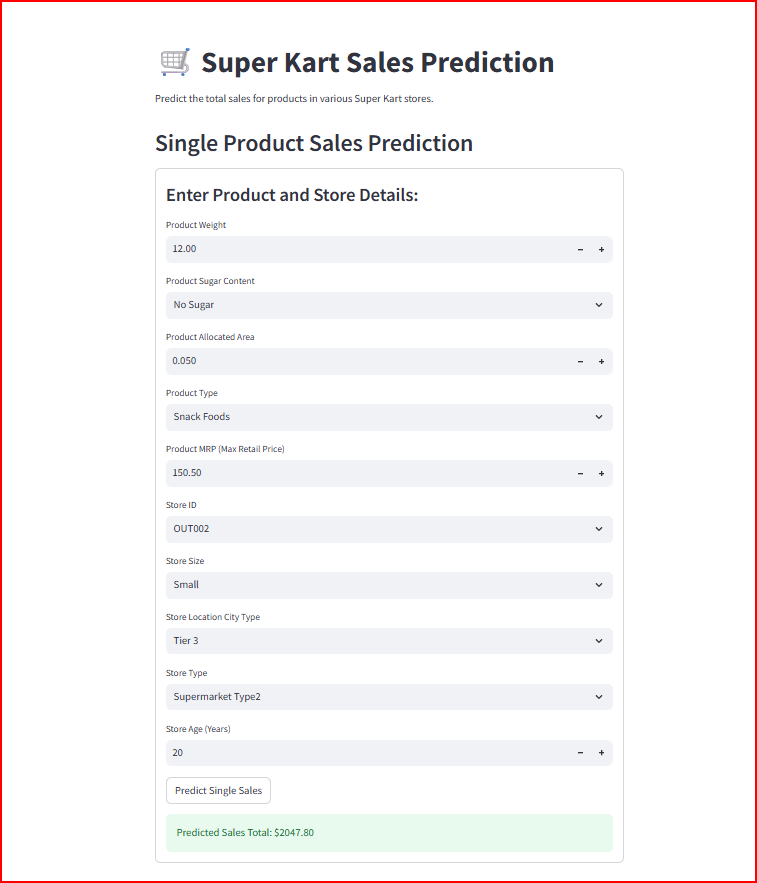

- Batch Sales Prediction:

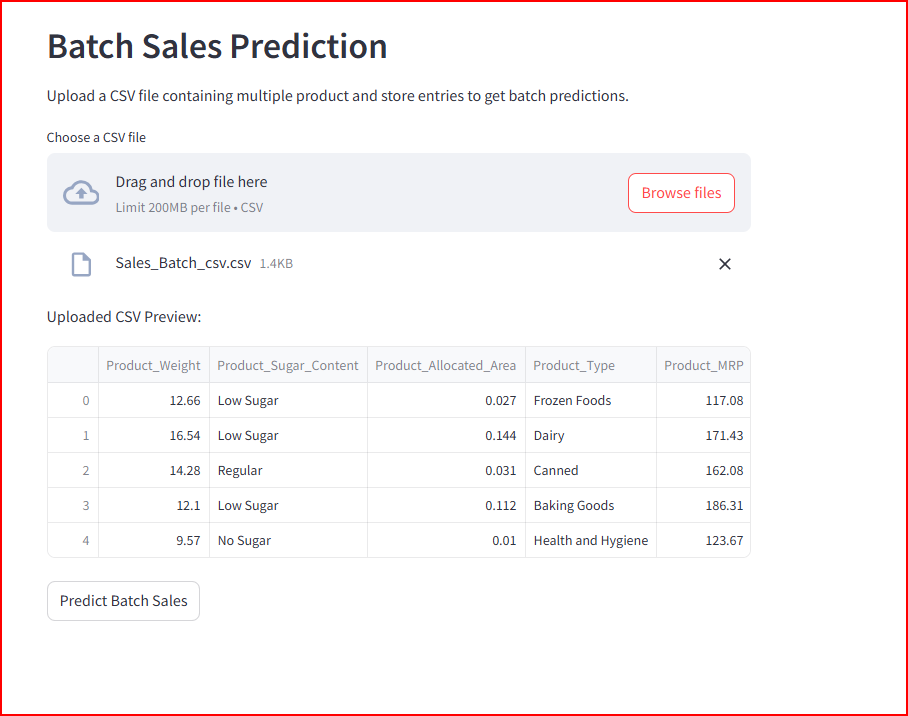

Batch Prediction screenshot:

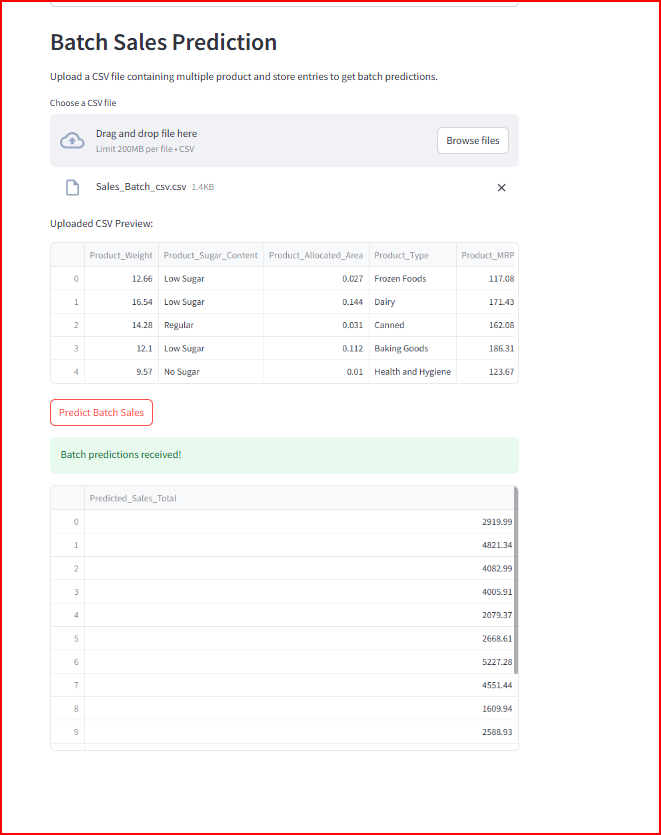


- Backend Link: https://huggingface.co/spaces/MadhaviSura/Super-Kart-Sales-Prediction-Backend



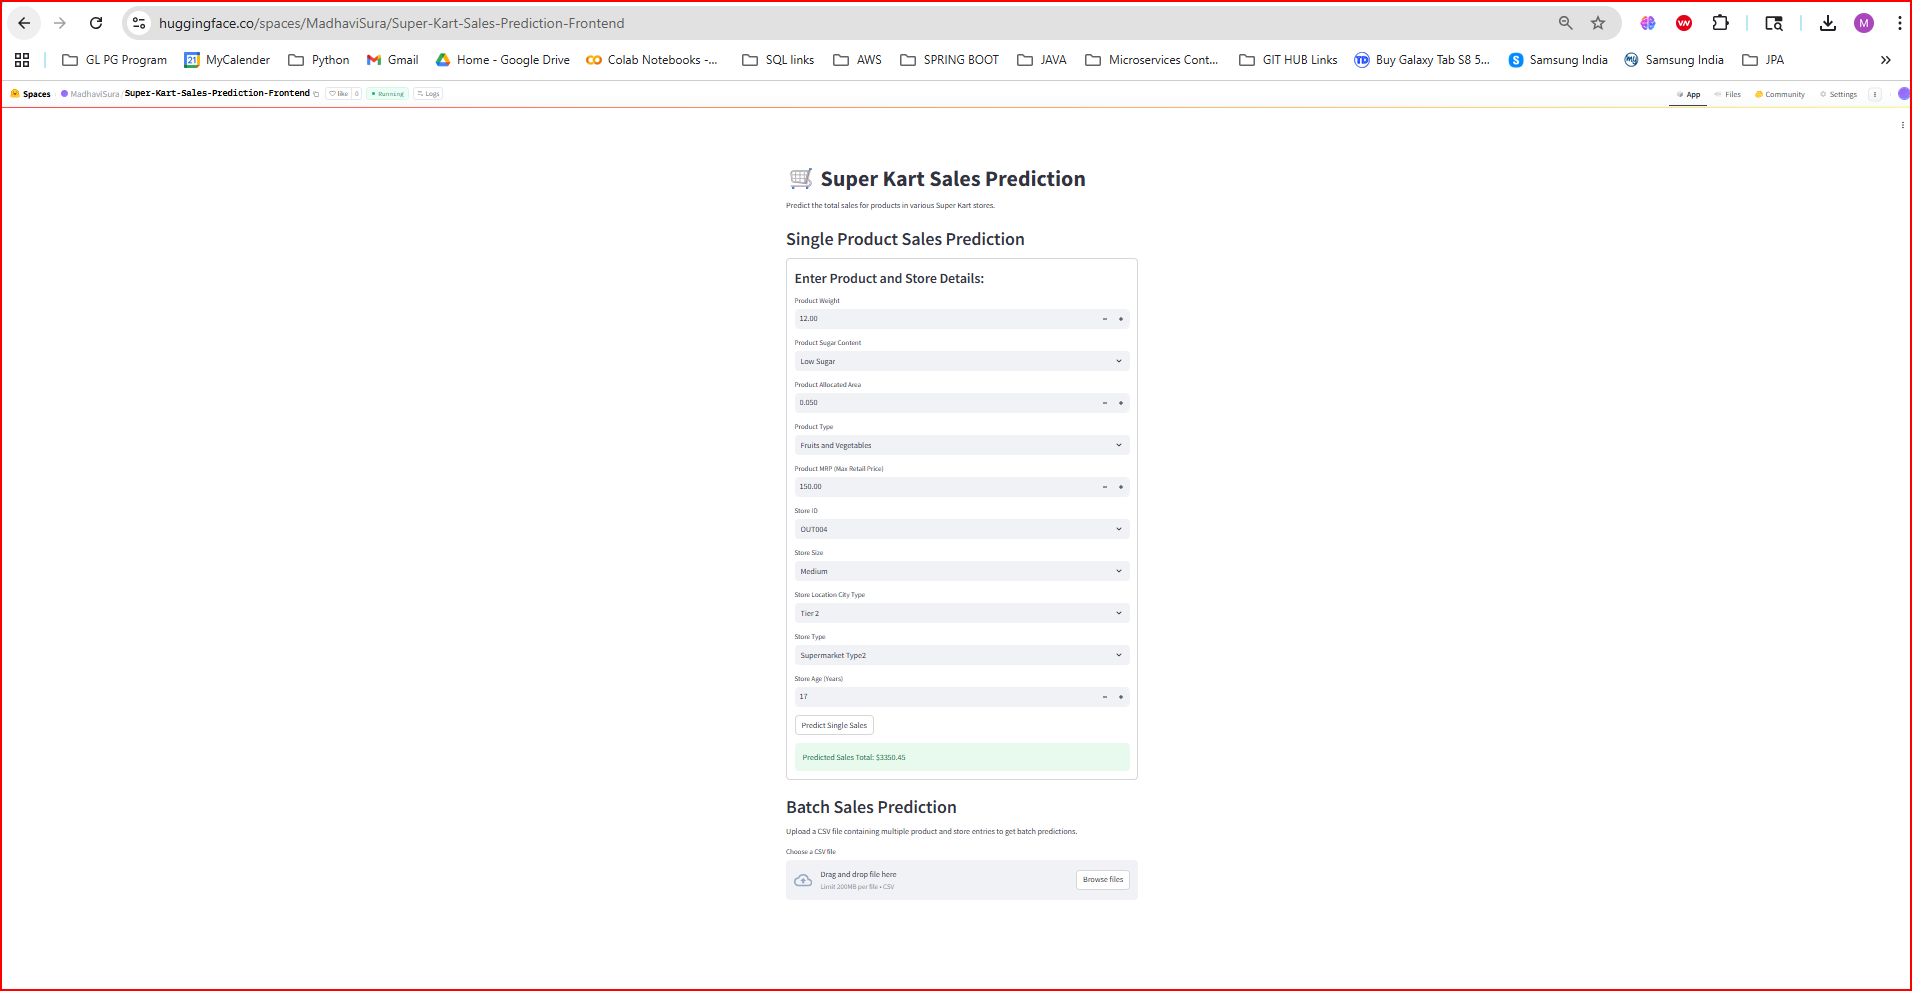



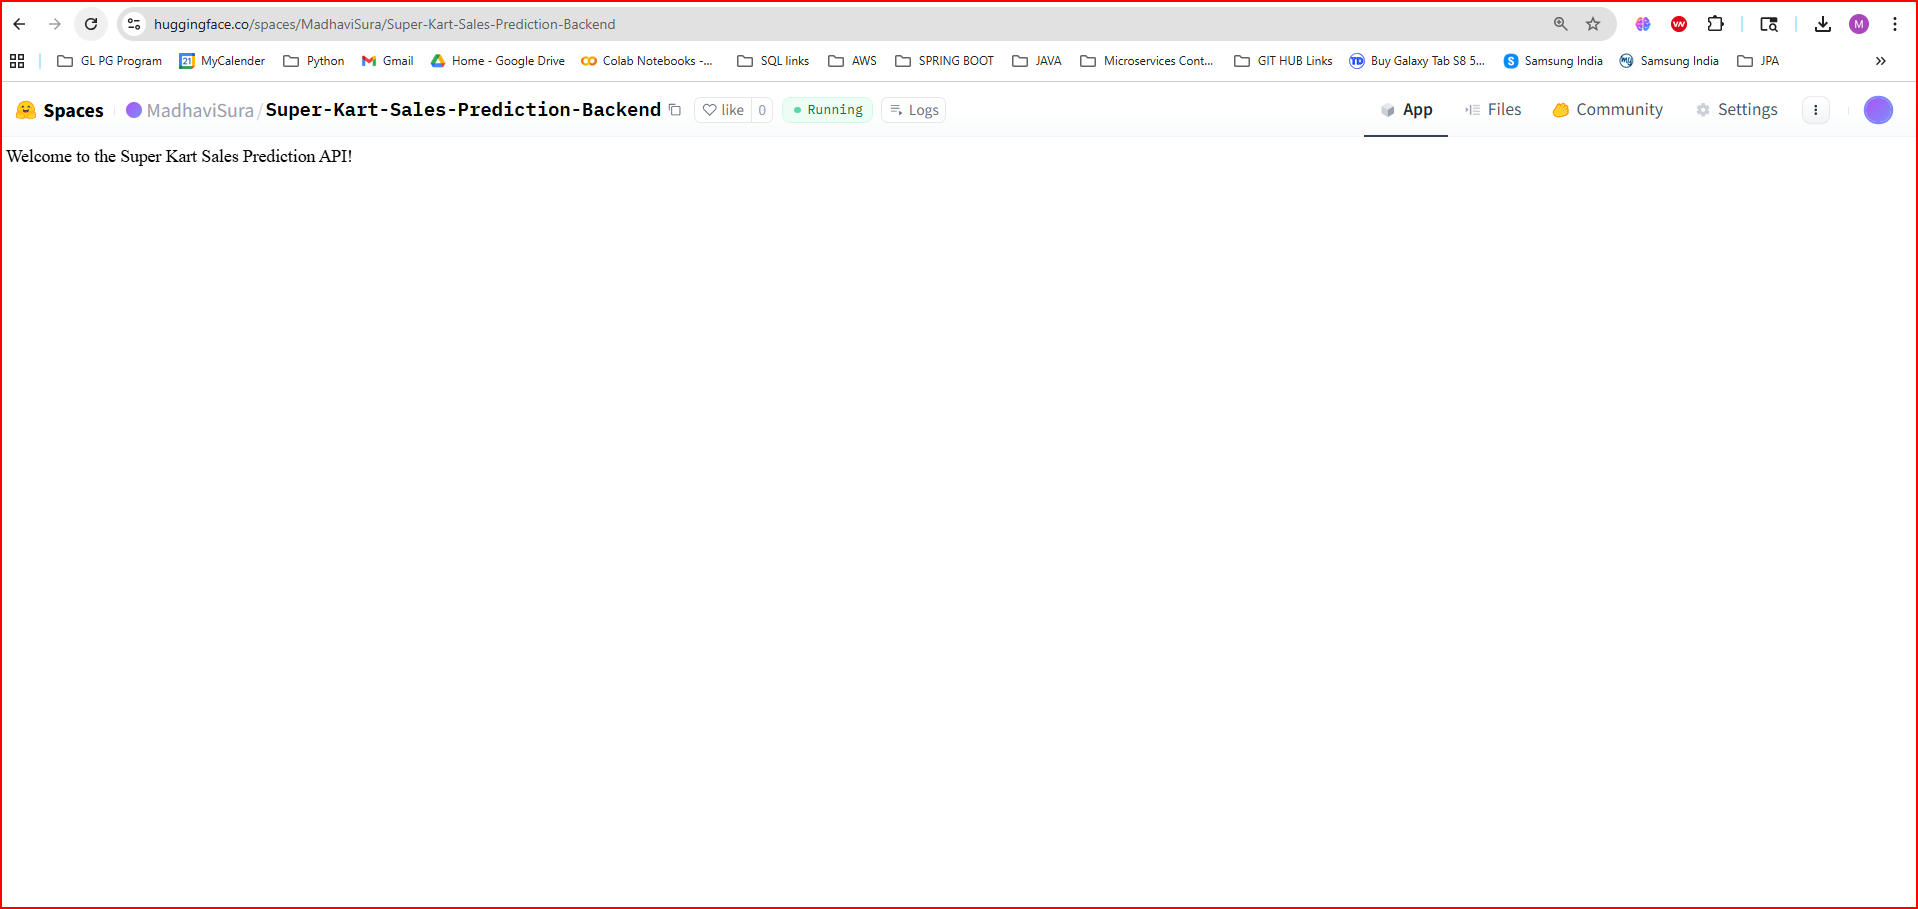



# **Actionable Insights and Business Recommendations**

### Model Performance Insights:

1.  **Overfitting Mitigation is Crucial**: Both Random Forest and XGBoost models initially exhibited significant overfitting, with very high R-squared scores on the training data but a noticeable drop on the test data. This highlighted the necessity of hyperparameter tuning to ensure robust performance on unseen data.

2.  **XGBoost Emerges as the Top Performer**: After hyperparameter tuning, the XGBoost Regressor demonstrated the best overall performance. It achieved the highest Adjusted R-squared (0.920) on the test set, coupled with the lowest RMSE (302.14) and MAE (135.58) among the tuned models. This indicates its superior ability to accurately forecast sales revenue for SuperKart.

3.  **Improved Generalization**: Hyperparameter tuning successfully reduced the overfitting in the XGBoost model. The gap between its training R-squared (0.938) and test R-squared (0.921) significantly narrowed, making it more reliable for real-world predictions than its untuned counterpart or the tuned Random Forest model.

### Business Recommendations:

1.  **Deploy the Tuned XGBoost Model for Sales Forecasting**: Given its superior performance and generalization capabilities, the tuned XGBoost model should be integrated into SuperKart’s decision-making systems. This will provide more accurate sales forecasts for optimizing inventory management and regional sales strategies.

2.  **Leverage Product Pricing for Revenue Growth**: The moderate positive correlation between `Product_MRP` and `Product_Store_Sales_Total` suggests that pricing is a significant lever. SuperKart should continuously analyze pricing strategies, potentially implementing dynamic pricing for high-value products or optimizing price points for different product categories to maximize revenue without negatively impacting sales volume.

3.  **Invest in High-Performing Stores and Replicate Success**: The EDA revealed significant sales disparities across `Store_Id`, `Store_Type` (Supermarket Type2), and `Store_Size` (High). A deep dive into the operations, customer demographics, and product mix of high-performing stores (e.g., 'OUT004', Supermarket Type2 stores, and larger stores) is crucial. Best practices should be identified and replicated across the entire network to uplift overall sales performance.

4.  **Strategic Expansion in Tier 2 Cities**: Stores located in 'Tier 2' cities showed the highest median sales. This suggests optimal market conditions in these areas. SuperKart should prioritize market research and expansion efforts in similar Tier 2 locations, as well as focus marketing and promotional activities on existing stores in these cities to further capitalize on their potential.

5.  **Optimize Product Assortment and Promotions**: The varying sales performance across `Product_Type` (e.g., 'Soft Drinks', 'Dairy', 'Snack Foods' performing well; 'Breakfast', 'Seafood' performing lower) highlights the need for a dynamic product assortment strategy. SuperKart should:
    *   Ensure adequate stock and promotional focus on high-demand product types.
    *   Evaluate the profitability and necessity of lower-performing categories, considering promotions, strategic placement, or even discontinuation if they are not core to the brand.

6.  **Re-evaluate Product Allocated Area Strategy**: The weak positive correlation between `Product_Allocated_Area` and sales indicates that simply increasing display space does not guarantee a proportional increase in sales. Instead, SuperKart should optimize product placement based on the predictive model's insights, sales velocity, and customer behavior data, rather than just physical area, to maximize the effectiveness of shelf space.

7.  **Data Consistency and Continuous Monitoring**: Ensure ongoing data quality, particularly by standardizing categorical features like `Product_Sugar_Content` (e.g., consistently mapping 'reg' to 'Regular'). Regular monitoring of the model's performance on new data is essential to identify any drift and trigger retraining to maintain forecasting accuracy.